In [1]:
import pylab as plt
import numpy as np
from cartopy import crs as ccrs
from netCDF4 import Dataset
import xarray as xr
from scipy import ndimage
from scipy.optimize import minimize
from scipy.interpolate import interp1d

import sys as sys
import glob as glob
import datetime as datetime

import seismic_LOPS as seismic
import matplotlib.colors as mcolors
import cmocean
import cmocean.cm as cmo
lightcmap = cmo.thermal  #tools.lighten(cmo.deep, 2)

plt.rcParams.update({'font.size': 18,'savefig.facecolor':'white'})

In [2]:
wave_spectrum_2D='CCI_WW3-GLOB-30M-Ekoundou_2023_spec.nc'
wave_spectrum_1D='CCI_WW3-GLOB-30M_202308_ef.nc'
bottom_topography_spectrum='spectrum_Ireland_shallow_rocks.bsp'
dpt=30     # adjusts water depth
CgR  =1800 # group speed of seismic waves, assumed constant

ds = Dataset(wave_spectrum_2D, "r")
# list variables in the file
print(ds.variables.keys())
# read the frequency variable
freq = ds.variables["frequency"][:]
lat  = ds.variables["latitude"][0,0]
lon  = ds.variables["longitude"][0,0]
time_spec = ds.variables["time"][:]
date1=time_spec[0]
date2=time_spec[-1]
station='EDA'
dA=1E8*3600
Q=np.array(freq)*0+400
lato, lono, thresh1, thresh2, thresh3, maxd, r, network, startdate=seismic.station_info(freq, station)

F_delta,Fx_delta,Fy_delta,Ef_spec,freqp,df,times1=seismic.seismic_response_primary_sandwaves_spec(wave_spectrum_2D, bottom_topography_spectrum, dpt, lat,lon, CgR,  Q,  lono, lato, dA, station)
print('shape:',np.shape(F_delta))


F_delta1,Ef_ef,freqp1,df1,times11=seismic.seismic_response_primary_sandwaves_ef_point(wave_spectrum_1D, bottom_topography_spectrum, dpt, lat,lon, CgR,  Q,  lono, lato, dA, station)
print('shape:',np.shape(F_delta1))




dict_keys(['time', 'station', 'string40', 'station_name', 'longitude', 'latitude', 'frequency', 'frequency1', 'frequency2', 'direction', 'efth', 'dpt', 'wnd', 'wnddir', 'cur', 'curdir'])
dth: 0.2617993877991494 24 8.3833 4.2833
alpha: 0.032050896612430074 1.1000000345150478
shape: (2920, 36)
Nearest longitude: 8.3833 8.0
Nearest latitude: 4.2833 4.0
shape: (744, 36, 317, 720)
alpha: 0.03769589132084607 1.1000000345150478
shape: (744, 36)


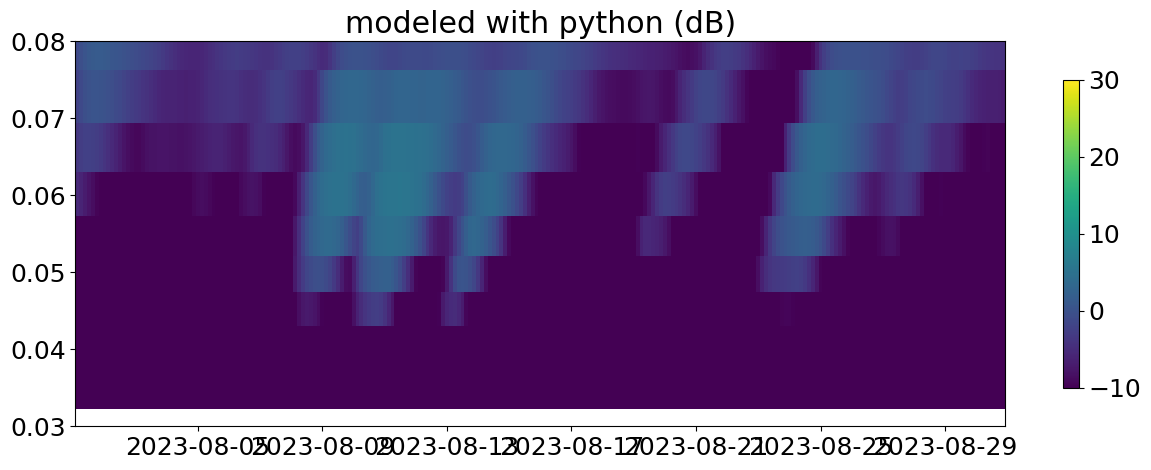

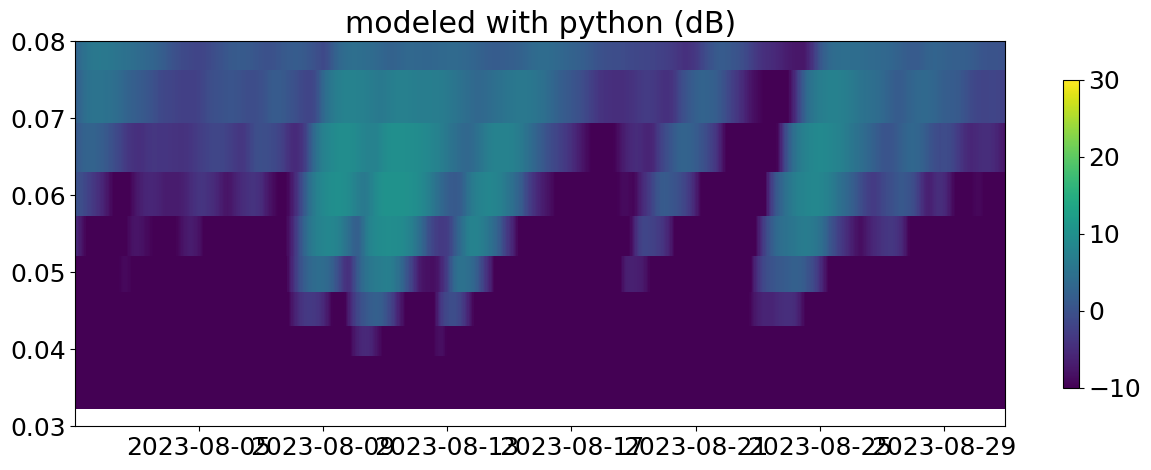

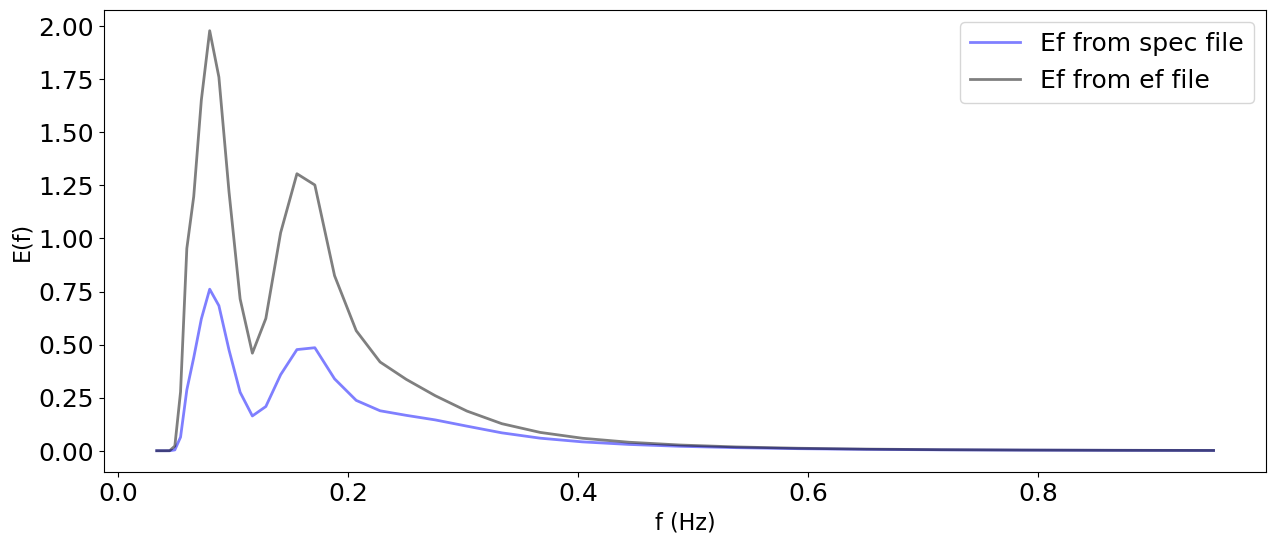

In [4]:
# Now we check that e(f) is indeed the sum of e(f,theta)
# the factor 3 difference when taking the nearest point in ef file is due to the sharp gradient 
# and the coarse resolution of the model grid (note that the E(f,theta) model output is obtained 
# by bilinear interpolation 



t1=np.datetime64('2023-08-01')
t2=np.datetime64('2023-08-31')
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
indsm=np.where((times1 > t1) & (times1 < t2))[0]
im=ax.pcolormesh(times1[indsm],freqp[0:10],10*np.log10(Ef_spec[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-10, vmax=30)
_=plt.colorbar(im,ax=ax,label='', location='right',shrink=0.8)
_=ax.set_title('modeled with python (dB)')
_=ax.set_ylim([0.03,0.08])

fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
indsm1=np.where((times11 > t1) & (times11 < t2))[0]
im=ax.pcolormesh(times11[indsm1],freqp1[0:10],10*np.log10(Ef_ef[indsm1,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-10, vmax=30)
_=plt.colorbar(im,ax=ax,label='', location='right',shrink=0.8)
_=ax.set_title('modeled with python (dB)')
_=ax.set_ylim([0.03,0.08])

fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,6))
ax.plot(freqp, Ef_spec[indsm[0],:], 'b-',alpha=0.5, label='Ef from spec file', linewidth=2)
ax.plot(freqp1, Ef_ef[indsm1[0],:], 'k-', alpha=0.5,label='Ef from ef file', linewidth=2)
ax.set_xlabel('f (Hz)', fontsize=16)
ax.set_ylabel('E(f)', fontsize=16)
plt.legend()

['2023-01-01T00:00:00'] ['2023-12-31T21:00:00']
['2023-01-01T00:00:00'] ['2023-12-31T21:00:00']
(53, 5400)
FRQ: (53,) [0.01166667 0.01333333 0.015      0.01666667 0.01833333 0.02
 0.02166667 0.02333333 0.025      0.02666667 0.02833333 0.03
 0.03166667 0.03333333 0.035      0.03666667 0.03833333 0.04
 0.04166667 0.04333333 0.045      0.04666667 0.04833333 0.05
 0.05166667 0.05333333 0.055      0.05666667 0.05833333 0.06
 0.06166667 0.06333333 0.065      0.06666667 0.06833333 0.07
 0.07166667 0.07333333 0.075      0.07666667 0.07833333 0.08
 0.08166667 0.08333333 0.085      0.08666667 0.08833333 0.09
 0.09166667 0.09333333]
SPEC: (5400, 53)
2023-01-01T00:00:00 2023-01-01T01:00:00 2024-01-01T22:59:59
(5400, 53) (5400,) (36,)
(2920, 36) (2920,) (36,)
(2920, 36) (2920,) (36,)
(744, 36) (2920,) (36,)
times11: 2023-08-01T00:00:00.000000000 2023-08-31T23:00:00.000000000 2023-08-01 2023-08-31
times11: 2023-08-01T00:00:00.000000000 2023-08-31T23:00:00.000000000 2023-08-01 2023-08-31 ## 1 719


/tmp/ipykernel_3493217/3239254078.py:46: RuntimeWarning: divide by zero encountered in log10
  im=ax.pcolormesh(times11[indsm],freqp1[0:10],10*np.log10(F_delta1[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)


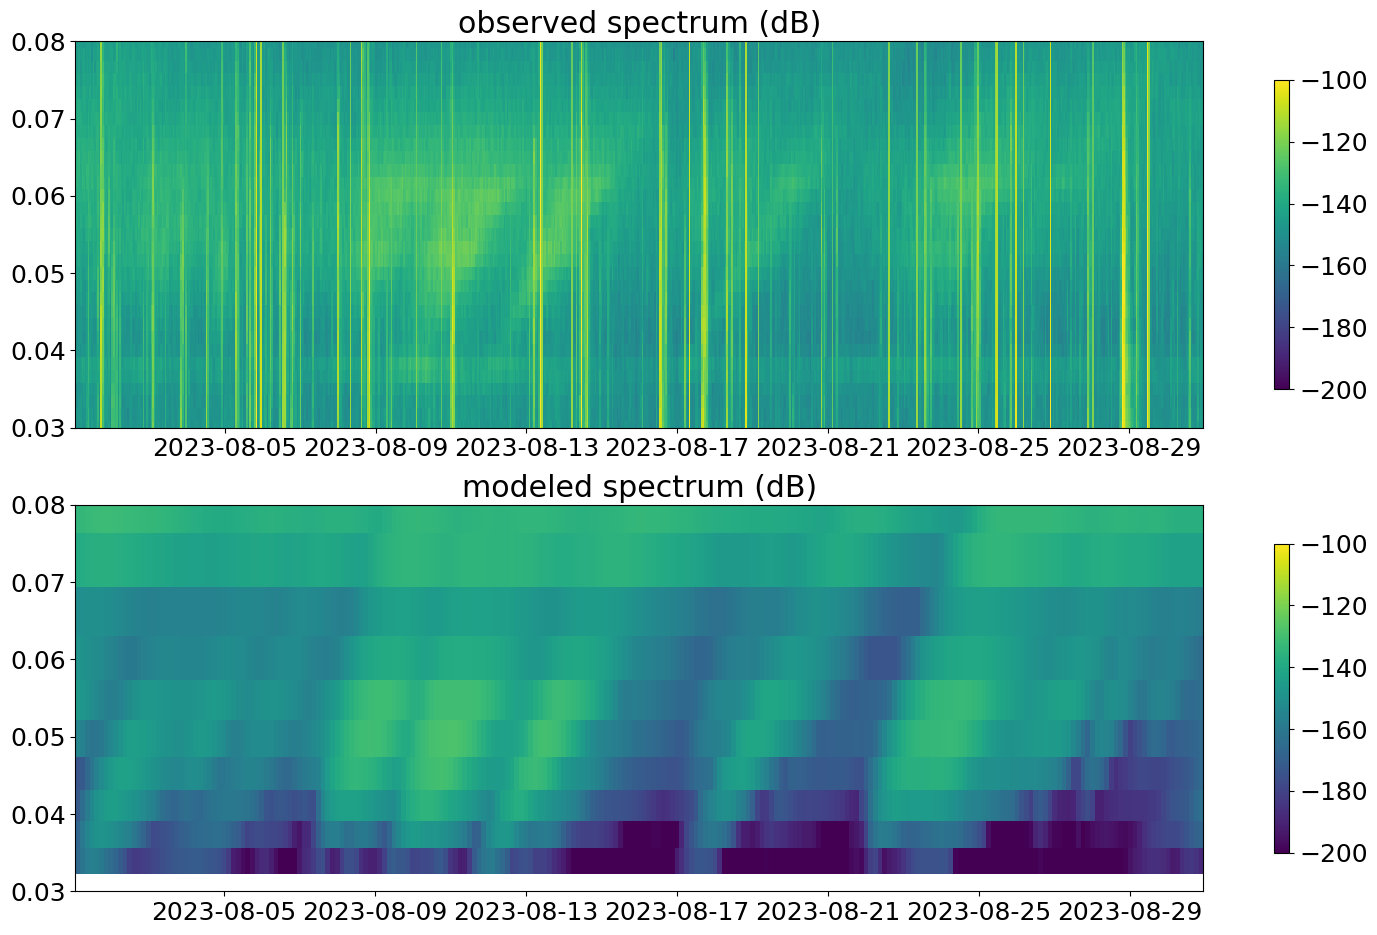

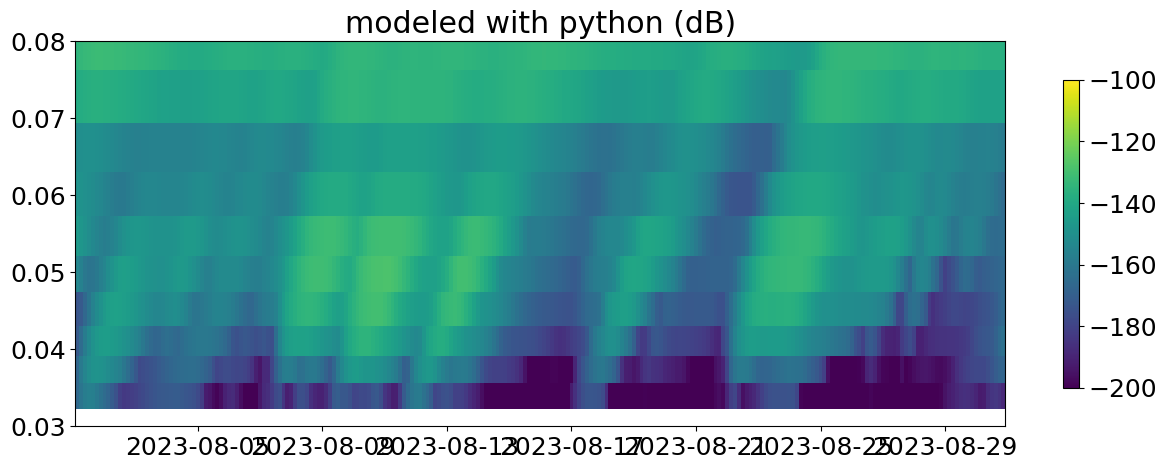

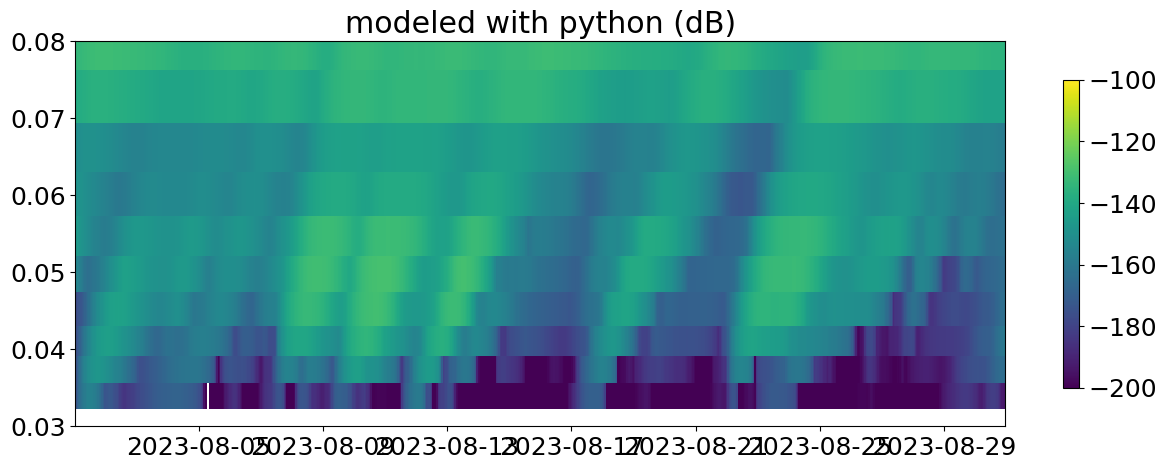

In [3]:
#times,freqp,Ef_pris,Q,lato,lono=import_synthetic_mat('EDA_PDC_GLOBAL05_202301_TEST471_REF102040Q400_150_primary.mat')
times,freqp,Ef_pris,Q,lato,lono=seismic.import_synthetic_mat('EDA_IRL_GLOBAL05_202301_CCI_WW3_Ekoundou_Q400_030_primary.mat')
times,freqp,Ef_pri2,Q,lato,lono=seismic.import_synthetic_mat('EDA_IRL_GLOBAL05_202301_CCI_WW3_Akpo_Q400_200_primary.mat')

# Warning: data from Piero is probably PSD of acceleration ... 
file='SpecEDA2023_psd.npz' # 'SpecEDA2023.npz'
date0, frq0, spectre0=seismic.read_sismo_npz(file)
print('FRQ:',np.shape(frq0),frq0[0:50])
print('SPEC:',np.shape(spectre0))
t1=np.datetime64('2023-08-01')
t2=np.datetime64('2023-08-31')
inds=np.where((date0 > t1) & (date0 < t2))[0]
print(date0[0],date0[1],date0[-1])
np.datetime64('2023-01-01')
fig, ax = plt.subplots(nrows=2, ncols=1,figsize=(15,10))
plt.subplots_adjust(left=0.05,bottom=0.07, top=0.92,wspace=0.12,right=0.99)
#im=ax[0].pcolormesh(10*np.log10(np.squeeze(spectre0)),cmap='viridis',rasterized=True) #,vmin=10, vmax=60)
print(np.shape(spectre0),np.shape(date0),np.shape(freqp))
im=ax[0].pcolormesh(date0[inds],frq0,10*np.log10(spectre0[inds,:].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax[0],label='', location='right',shrink=0.8)
_=ax[0].set_title('observed spectrum (dB)')
#_=ax[0].set_ylim([0.03,0.08])
_=ax[0].set_ylim([0.03,0.08])

print(np.shape(Ef_pris),np.shape(times),np.shape(freqp))
indsm=np.where((times > t1) & (times < t2))[0]
im=ax[1].pcolormesh(times[indsm],freqp[0:10],10*np.log10(3600*Ef_pris[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax[1],label='', location='right',shrink=0.8)
_=ax[1].set_title('modeled spectrum (dB)')
_=ax[1].set_ylim([0.03,0.08])


fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
print(np.shape(F_delta),np.shape(times),np.shape(freqp))
indsm=np.where((times1 > t1) & (times1 < t2))[0]
im=ax.pcolormesh(times1[indsm],freqp[0:10],10*np.log10(F_delta[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax,label='', location='right',shrink=0.8)
_=ax.set_title('modeled with python (dB)')
_=ax.set_ylim([0.03,0.08])

fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,5))
print(np.shape(F_delta1),np.shape(times),np.shape(freqp))
print('times11:',times11[0].values,times11[-1].values,t1,t2)
indsm=np.where((times11 > t1) & (times11 < t2))[0]
print('times11:',times11[0].values,times11[-1].values,t1,t2,'##',indsm[0],indsm[-1])
im=ax.pcolormesh(times11[indsm],freqp1[0:10],10*np.log10(F_delta1[indsm,0:10].T),cmap='viridis',rasterized=True, shading='nearest',vmin=-200, vmax=-100)
_=plt.colorbar(im,ax=ax,label='', location='right',shrink=0.8)
_=ax.set_title('modeled with python (dB)')
_=ax.set_ylim([0.03,0.08])

In [4]:
freqs=freqp
dfs=freqp*0.5*(1.1-1/1.1)
rs=dfs*0
print(lato,lono,freqs.shape)
# Set up paths
station='EDA' 
year=2023
yname = str(year)  # Replace with your desired year
#lato, lono, thresh1, thresh2, thresh3, maxd, rs, network, startdate=seismic.station_info(freqs, station)

ifmin = 1  # 0.1 
ifmax = 5 # 0.25

#ifmin = 5  # 0.1 
#ifmax = 8 # 0.25

print('Freq:',freqs[ifmin]*0.95,freqs[ifmax-1]*1.05)
# Assuming `date0` and `times` are datetime64 objects
base_date = np.datetime64('1970-01-01')  # You can use any base date, like '1970-01-01'

# Convert `date0` and `times` into seconds since the base date (this assumes `date0` and `times` are datetime64)
date0_seconds = (date0 - base_date) / np.timedelta64(1, 's')
times_seconds = (times - base_date) / np.timedelta64(1, 's')

# Now you can safely divide them by np.timedelta64(1, 's') if needed
delta_obs = seismic.compute_delta_obs(spectre0, frq0, freqs, ifmin, ifmax, date0_seconds, times_seconds,smooth=2,percentile=0)
delta_Eko, delta_ref = seismic.compute_delta_model(Ef_pris, Ef_pris, dfs, rs, ifmin, ifmax)
delta_Eko2, delta_ref = seismic.compute_delta_model(F_delta, F_delta, dfs, rs, ifmin, ifmax)
delta_Eko3, delta_ref = seismic.compute_delta_model(F_delta1, F_delta1, dfs, rs, ifmin, ifmax)
delta_Akp, delta_ref = seismic.compute_delta_model(Ef_pri2, Ef_pri2, dfs, rs, ifmin, ifmax)





3.778868 10.153427 (36,)
Freq: 0.03542549945414066 0.05211463831365109
df2: (2920, 36)
df2: (2920, 36)
df2: (744, 36)
df2: (2920, 36)


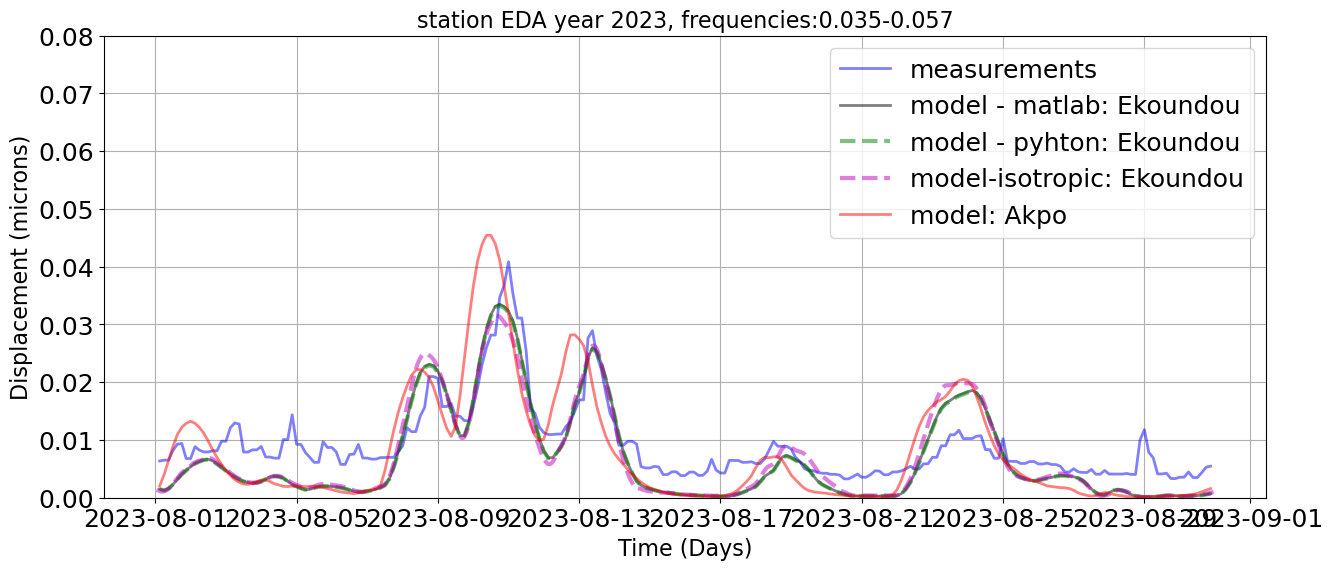

In [6]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(15,6))
P=60

t1=np.datetime64('2023-08-01')
t2=np.datetime64('2023-08-31')
inds=np.where((times > t1) & (times < t2))[0]
inds1=np.where((times11 > t1) & (times11 < t2))[0]

ax.plot(times[inds], delta_obs[inds], 'b-',alpha=0.5, label='measurements', linewidth=2)
ax.plot(times[inds], delta_Eko[inds] * P, 'k-', alpha=0.5,label='model - matlab: Ekoundou', linewidth=2)
ax.plot(times[inds], delta_Eko2[inds] , 'g--', alpha=0.5,label='model - pyhton: Ekoundou', linewidth=3)
ax.plot(times11[inds1], delta_Eko3[inds1] , 'm--', alpha=0.5,label='model-isotropic: Ekoundou', linewidth=3)
ax.plot(times[inds], delta_Akp[inds] * P, 'r-', alpha=0.5,label='model: Akpo', linewidth=2)
#ax.plot(times, delta_PDC * P, 'k-', alpha=0.5,label='model: sandwaves', linewidth=2)
ax.set_xlabel('Time (Days)', fontsize=16)
ax.set_ylabel('Displacement (microns)', fontsize=16)
ax.set_ylim([0,0.08])
freqstring=f'{freqs[ifmin]*0.95:4.3f}'+'-'+f'{freqs[ifmax]*1.05:4.3f}'
ax.set_title('station '+station+' year '+yname+ ', frequencies:'+freqstring, fontsize=16)
plt.legend()
plt.grid(True)
        
plt.savefig('timeseries_freqs_newEDA'+freqstring+'.png')
